# `03 — Sorting Algorithms (O(N^2), Counting Sort, Lower Bound Proof)`

We study:
- **Sorting problem statement** (as permutation)
- **O(N^2)** sorting algorithms:
  - **Selection sort**
  - **Insertion sort**
  - **Bubble sort**
- **Counting sort** (**O(N + M)** with limitations)
- **Proof**: Sorting by **pairwise comparisons** faster than **O(N log N)** is impossible

Goal:
- Know ideas + **Big-O**
- Be able to **explain step-by-step**
- Be able to reproduce the **lower bound proof**

## `1. Sorting problem statement`

### `1.1 What is sorting?`

Input:
- Sequence: x0, x1, ..., x(N-1)

Output:
- A **permutation of indices** π = (i0, i1, ..., i(N-1))
such that:

**x[i0] ≤ x[i1] ≤ ... ≤ x[i(N-1)]**

So sorting is basically:
- find the **correct order**
- i.e. find the correct **permutation** that makes the sequence non-decreasing

## `2. O(N^2) sorting algorithms`

### `2.0 Complexity summary:`

| Algorithm | Best | Average | Worst | Extra memory | Stable? |
|---|---:|---:|---:|---:|---:|
| **Selection sort** | O(N^2) | O(N^2) | O(N^2) | O(1) | No (usually) |
| **Insertion sort** | **O(N)** (already sorted) | O(N^2) | O(N^2) | O(1) | **Yes** |
| **Bubble sort** | O(N) with “early stop” | O(N^2) | O(N^2) | O(1) | Yes |

### `2.1 Selection sort:`

**Idea:**
- For position i = 0..N-1:
  - find the **minimum** in x[i..N)
  - swap it into position i

Like: “select the smallest remaining element and put it in front”.

**Complexity:**
- comparisons: (N-1) + (N-2) + ... + 1 = N(N-1)/2 = **O(N^2)**

In [ ]:
from typing import List, Tuple


def selection_sort_trace(x: List[int], *, verbose: bool = True) -> Tuple[List[int], int, int]:
    """
    Returns:
      (sorted_list, comparisons, swaps)
    """
    a: List[int] = x.copy()
    n: int = len(a)
    comparisons: int = 0
    swaps: int = 0

    if verbose:
        print(f"start: {a}")

    for i in range(n - 1):
        
        i_min: int = i
        
        for j in range(i + 1, n):
            comparisons += 1

            if a[j] < a[i_min]:
                i_min = j

        if i_min != i:
            a[i], a[i_min] = a[i_min], a[i]
            swaps += 1

        if verbose:
            print(f"i={i:>2} -> {a}   (min_idx={i_min})")

    return a, comparisons, swaps


# Example 01: random
print("-" * 55)
print(f"{'Selection Sort — Example 01 (random)':^55}")
print("-" * 55)
sorted_a, comps, sws = selection_sort_trace([4, 2, 5, 6, 3, 1, 7, 8], verbose=True)
print(f"sorted={sorted_a}, comparisons={comps}, swaps={sws}")

-------------------------------------------------------
         Selection Sort — Example 01 (random)          
-------------------------------------------------------
start: [4, 2, 5, 6, 3, 1, 7, 8]
i= 0 -> [1, 2, 5, 6, 3, 4, 7, 8]   (min_idx=5)
i= 1 -> [1, 2, 5, 6, 3, 4, 7, 8]   (min_idx=1)
i= 2 -> [1, 2, 3, 6, 5, 4, 7, 8]   (min_idx=4)
i= 3 -> [1, 2, 3, 4, 5, 6, 7, 8]   (min_idx=5)
i= 4 -> [1, 2, 3, 4, 5, 6, 7, 8]   (min_idx=4)
i= 5 -> [1, 2, 3, 4, 5, 6, 7, 8]   (min_idx=5)
i= 6 -> [1, 2, 3, 4, 5, 6, 7, 8]   (min_idx=6)
sorted=[1, 2, 3, 4, 5, 6, 7, 8], comparisons=28, swaps=3


### `2.2 Insertion sort`

**Idea (cards in hand):**
- Maintain a **sorted left part**
- Take next element ("key") and **insert** it into the correct place in the left part
- This insertion happens by shifting bigger elements to the right

**Key observation:**
- If the array is already almost sorted, insertion sort can be **very fast**

**Complexity:**
- Worst case (reverse sorted): shifts ~ 1 + 2 + ... + (N-1) = **O(N^2)**
- Best case (already sorted): inner loop almost never runs → **O(N)**


In [2]:
from typing import List, Tuple


def insertion_sort_trace(x: List[int], *, verbose: bool = True) -> Tuple[List[int], int, int]:
    """
    Returns:
      (sorted_list, comparisons, shifts)
    """
    a: List[int] = x.copy()
    n: int = len(a)
    comparisons: int = 0
    shifts: int = 0

    if verbose:
        print(f"start: {a}")

    for i in range(1, n):
        key: int = a[i]
        j: int = i - 1

        while j >= 0:
            comparisons += 1
            if key < a[j]:
                a[j + 1] = a[j]
                shifts += 1
                j -= 1
            else:
                break

        a[j + 1] = key

        if verbose:
            print(f"i={i:>2}, key={key:>2} -> {a}")

    return a, comparisons, shifts


# Example 01: random
print("-" * 55)
print(f"{'Insertion Sort — Example 01 (random)':^55}")
print("-" * 55)
sorted_a, comps, shifts = insertion_sort_trace([4, 2, 5, 6, 3, 1, 7, 8], verbose=True)
print(f"sorted={sorted_a}, comparisons={comps}, shifts={shifts}")

# Example 02: nearly sorted (shows why it can be O(N))
print("-" * 55)
print(f"{'Insertion Sort — Example 02 (nearly sorted)':^55}")
print("-" * 55)
sorted_a, comps, shifts = insertion_sort_trace([1, 2, 3, 4, 6, 5, 7, 8], verbose=True)
print(f"sorted={sorted_a}, comparisons={comps}, shifts={shifts}")


-------------------------------------------------------
         Insertion Sort — Example 01 (random)          
-------------------------------------------------------
start: [4, 2, 5, 6, 3, 1, 7, 8]
i= 1, key= 2 -> [2, 4, 5, 6, 3, 1, 7, 8]
i= 2, key= 5 -> [2, 4, 5, 6, 3, 1, 7, 8]
i= 3, key= 6 -> [2, 4, 5, 6, 3, 1, 7, 8]
i= 4, key= 3 -> [2, 3, 4, 5, 6, 1, 7, 8]
i= 5, key= 1 -> [1, 2, 3, 4, 5, 6, 7, 8]
i= 6, key= 7 -> [1, 2, 3, 4, 5, 6, 7, 8]
i= 7, key= 8 -> [1, 2, 3, 4, 5, 6, 7, 8]
sorted=[1, 2, 3, 4, 5, 6, 7, 8], comparisons=14, shifts=9
-------------------------------------------------------
      Insertion Sort — Example 02 (nearly sorted)      
-------------------------------------------------------
start: [1, 2, 3, 4, 6, 5, 7, 8]
i= 1, key= 2 -> [1, 2, 3, 4, 6, 5, 7, 8]
i= 2, key= 3 -> [1, 2, 3, 4, 6, 5, 7, 8]
i= 3, key= 4 -> [1, 2, 3, 4, 6, 5, 7, 8]
i= 4, key= 6 -> [1, 2, 3, 4, 6, 5, 7, 8]
i= 5, key= 5 -> [1, 2, 3, 4, 5, 6, 7, 8]
i= 6, key= 7 -> [1, 2, 3, 4, 5, 6, 7, 8]
i= 7, key

### `2.3 Bubble sort`

**Idea:**
- Repeatedly compare neighbors (x[j], x[j+1])
- If they are in wrong order, swap them
- After one full pass, the **maximum “bubbles up”** to the end

If we add a flag “did we swap anything?”, then:
- Best case (already sorted) can be **O(N)**

**Complexity:**
- Worst case comparisons: 1 + 2 + ... + (N-1) = **O(N^2)**


In [3]:
from typing import List, Tuple


def bubble_sort_trace(x: List[int], *, verbose: bool = True) -> Tuple[List[int], int, int]:
    """
    Returns:
      (sorted_list, comparisons, swaps)
    """
    a: List[int] = x.copy()
    n: int = len(a)
    comparisons: int = 0
    swaps: int = 0

    if verbose:
        print(f"start: {a}")

    for i in range(n - 1):
        swapped: bool = False
        for j in range(0, n - i - 1):
            comparisons += 1
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                swaps += 1
                swapped = True

        if verbose:
            print(f"pass={i:>2} -> {a}   swapped={swapped}")

        if not swapped:
            break

    return a, comparisons, swaps


# Example 01: random
print("-" * 55)
print(f"{'Bubble Sort — Example 01 (random)':^55}")
print("-" * 55)
sorted_a, comps, sws = bubble_sort_trace([4, 2, 5, 6, 3, 1, 7, 8], verbose=True)
print(f"sorted={sorted_a}, comparisons={comps}, swaps={sws}")

# Example 02: already sorted (shows early stop)
print("-" * 55)
print(f"{'Bubble Sort — Example 02 (already sorted)':^55}")
print("-" * 55)
sorted_a, comps, sws = bubble_sort_trace([1, 2, 3, 4, 5, 6, 7, 8], verbose=True)
print(f"sorted={sorted_a}, comparisons={comps}, swaps={sws}")


-------------------------------------------------------
           Bubble Sort — Example 01 (random)           
-------------------------------------------------------
start: [4, 2, 5, 6, 3, 1, 7, 8]
pass= 0 -> [2, 4, 5, 3, 1, 6, 7, 8]   swapped=True
pass= 1 -> [2, 4, 3, 1, 5, 6, 7, 8]   swapped=True
pass= 2 -> [2, 3, 1, 4, 5, 6, 7, 8]   swapped=True
pass= 3 -> [2, 1, 3, 4, 5, 6, 7, 8]   swapped=True
pass= 4 -> [1, 2, 3, 4, 5, 6, 7, 8]   swapped=True
pass= 5 -> [1, 2, 3, 4, 5, 6, 7, 8]   swapped=False
sorted=[1, 2, 3, 4, 5, 6, 7, 8], comparisons=27, swaps=9
-------------------------------------------------------
       Bubble Sort — Example 02 (already sorted)       
-------------------------------------------------------
start: [1, 2, 3, 4, 5, 6, 7, 8]
pass= 0 -> [1, 2, 3, 4, 5, 6, 7, 8]   swapped=False
sorted=[1, 2, 3, 4, 5, 6, 7, 8], comparisons=7, swaps=0


## `3. Counting sort (linear with limitations)`:

### `3.1 Why counting sort is possible`

The “impossible to beat O(N log N)” result is for sorting that works **only by comparisons**.

Counting sort works because we assume:
- values are integers in a **small range**: 0..M
- and M is “not too large” (often M ~ N)

Then we can count frequencies instead of comparing elements.

**Complexity:**
- Build counts: O(N)
- Rebuild result: O(N + M)
So total: **O(N + M)** (linear if M is small / comparable to N)


In [5]:
# Counting sort (simple version)
from typing import List

def counting_sort_simple(x: List[int]) -> List[int]:
    if len(x) == 0:
        return []

    m: int = max(x) + 1
    cnt: List[int] = [0] * m

    for v in x:
        cnt[v] += 1

    res: List[int] = []
    for value in range(m):
        for _ in range(cnt[value]):
            res.append(value)

    return res


print("-" * 55)
print(f"{'Counting Sort — Example 01':^55}")
print("-" * 55)

arr = [0, 2, 1, 1, 0, 1, 0, 0]
print("input :", arr)
print("sorted:", counting_sort_simple(arr))

-------------------------------------------------------
              Counting Sort — Example 01               
-------------------------------------------------------
input : [0, 2, 1, 1, 0, 1, 0, 0]
sorted: [0, 0, 0, 0, 1, 1, 1, 2]


In [ ]:
# Counting sort (stable version) 
from typing import List


def counting_sort_stable(x: List[int]) -> List[int]:

    if len(x) == 0:
        return []

    n: int = len(x)
    m: int = max(x) + 1

    c: List[int] = [0] * m
    for v in x:
        c[v] += 1

    for i in range(1, m):
        c[i] += c[i - 1]

    res: List[int] = [0] * n
    for i in range(n):
        position: int = c[x[i]] - 1
        res[position] = x[i]
        c[x[i]] -= 1

    return res


print("-" * 55)
print(f"{'Counting Sort (stable) — Example 02':^55}")
print("-" * 55)

arr = [2, 0, 2, 1, 1, 0]
print("input :", arr)
print("sorted:", counting_sort_stable(arr))


-------------------------------------------------------
          Counting Sort (stable) — Example 02          
-------------------------------------------------------
input : [2, 0, 2, 1, 1, 0]
sorted: [0, 0, 1, 1, 2, 2]


## `4. Proof: faster than O(N log N) comparisons is impossible`

### `4.1 Decision tree model for comparison sorting`

A comparison-based sorting algorithm:
- compares pairs: **x[i] ≤ x[j]?**
- depending on YES/NO, it chooses the next step

So the algorithm’s behavior can be represented as a **binary decision tree**:
- each internal node = one comparison
- each branch = comparison result (yes/no)
- each leaf = final output permutation π


### `4.2 Why the tree must have at least N! leaves`

If all N elements are distinct:
- there are **N! possible input orders**
- and each different input order can require a different output permutation π

A correct sorting algorithm must be able to end in a leaf that corresponds to the correct permutation.
So the decision tree needs at least one leaf per possible permutation:

**k ≥ N!**


### `4.3 Height and comparisons`

A binary tree with height H can have at most 2^H leaves.

So:
k ≤ 2^H   ⇒   H ≥ log2(k)

Combine with k ≥ N!:
**H ≥ log2(N!)**

### `4.4 Show log2(N!) = Ω(N log N)`

We can lower bound N! without full Stirling:

N! = 1 · 2 · 3 · ... · N

At least N/2 of these factors are ≥ N/2, so:
N! ≥ (N/2)^(N/2)

Take log2:
log2(N!) ≥ log2((N/2)^(N/2))
         = (N/2) · log2(N/2)
         = (N/2) · (log2 N - 1)
         = Ω(N log N)

Therefore:
Any comparison-based sorting algorithm needs
**Ω(N log N)** comparisons in the worst case.

### `4.5 Conclusion`

So:
- **Selection / insertion / bubble** are O(N^2)
- **Merge sort / quick sort** can do O(N log N)
- But **no comparison-only** sorting algorithm can beat **Ω(N log N)** in worst case

To go below O(N log N), we must use **additional assumptions** (like counting sort’s small integer range).

## `EXTRA`:

### `Selection vs Insertion vs Bubble (small N):`


In [1]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Tuple

# ---------------------------------------------------------
# O(n^2) Sorting algorithms (educational implementations)
# ---------------------------------------------------------

def selection_sort(a: List[int]) -> List[int]:
    b: List[int] = a.copy()
    n: int = len(b)

    for i in range(n - 1):
        i_min: int = i
        for j in range(i + 1, n):
            if b[j] < b[i_min]:
                i_min = j
        if i_min != i:
            b[i], b[i_min] = b[i_min], b[i]
    return b


def insertion_sort(a: List[int]) -> List[int]:
    b: List[int] = a.copy()
    n: int = len(b)

    for i in range(1, n):
        key: int = b[i]
        j: int = i - 1
        while j >= 0 and key < b[j]:
            b[j + 1] = b[j]
            j -= 1
        b[j + 1] = key
    return b


def bubble_sort(a: List[int]) -> List[int]:
    b: List[int] = a.copy()
    n: int = len(b)

    for i in range(n - 1):
        swapped: bool = False
        for j in range(0, n - i - 1):
            if b[j] > b[j + 1]:
                b[j], b[j + 1] = b[j + 1], b[j]
                swapped = True
        if not swapped:
            break
    return b

# ---------------------------------------------------------
# Benchmark helper
# ---------------------------------------------------------

def time_call(fn: Callable[[], None], *, repeats: int) -> float:
    """
    Returns median time (seconds) across repeats to reduce noise.
    """
    times: List[float] = []
    for _ in range(repeats):
        t0: float = time.perf_counter()
        fn()
        t1: float = time.perf_counter()
        times.append(t1 - t0)
    times.sort()
    return times[len(times) // 2]



In [2]:
# ---------------------------------------------------------
# Experiment setup (small N because O(n^2))
# ---------------------------------------------------------

random.seed(7)

ns: List[int] = [50, 80, 120, 160, 200, 240, 280, 320, 360, 400, 450, 500, 600, 700, 800, 900, 1000, 1200, 1500, 1800, 2000]
datasets: Dict[int, List[int]] = {n: [random.randint(0, 10_000) for _ in range(n)] for n in ns}

algs: List[Tuple[str, Callable[[List[int]], List[int]]]] = [
    ("Selection sort  (O(n^2))", selection_sort),
    ("Insertion sort  (O(n^2), best O(n))", insertion_sort),
    ("Bubble sort     (O(n^2), early stop)", bubble_sort),
]

repeats: int = 5  # small sizes -> safe

results: Dict[str, List[float]] = {name: [] for name, _ in algs}

print("-" * 70)
print(f"{'Benchmark: O(n^2) sorting algorithms (small N)':^70}")
print("-" * 70)

for n in ns:
    arr = datasets[n]
    print(f"N={n}")
    for name, alg in algs:
        elapsed = time_call(fn=lambda alg=alg, arr=arr: alg(arr), repeats=repeats)
        results[name].append(elapsed)
        print(f"  {name:<35}  {elapsed:.6f} s")
    print()
print("-" * 70)
# ---------------------------------------------------------


----------------------------------------------------------------------
            Benchmark: O(n^2) sorting algorithms (small N)            
----------------------------------------------------------------------
N=50
  Selection sort  (O(n^2))             0.000033 s
  Insertion sort  (O(n^2), best O(n))  0.000030 s
  Bubble sort     (O(n^2), early stop)  0.000050 s

N=80
  Selection sort  (O(n^2))             0.000066 s
  Insertion sort  (O(n^2), best O(n))  0.000075 s
  Bubble sort     (O(n^2), early stop)  0.000135 s

N=120
  Selection sort  (O(n^2))             0.000178 s
  Insertion sort  (O(n^2), best O(n))  0.000166 s
  Bubble sort     (O(n^2), early stop)  0.000382 s

N=160
  Selection sort  (O(n^2))             0.000353 s
  Insertion sort  (O(n^2), best O(n))  0.000298 s
  Bubble sort     (O(n^2), early stop)  0.000590 s

N=200
  Selection sort  (O(n^2))             0.000407 s
  Insertion sort  (O(n^2), best O(n))  0.000448 s
  Bubble sort     (O(n^2), early stop)  0.000930 s


In [3]:
results
df_dict = {
    "N": ns,
    'Selectio Sort': results['Selection sort  (O(n^2))'],
    'Insertion Sort': results['Insertion sort  (O(n^2), best O(n))'],
    'Bubble Sort': results['Bubble sort     (O(n^2), early stop)'],
}

df = pd.DataFrame(
    data=df_dict, 
    columns=['N', 'Selectio Sort', 'Insertion Sort', 'Bubble Sort'], 
)
df


,N,Selectio Sort,Insertion Sort,Bubble Sort
0,50,0.000033,0.000030,0.000050
1,80,0.000066,0.000075,0.000135
2,120,0.000178,0.000166,0.000382
3,160,0.000353,0.000298,0.000590
4,200,0.000407,0.000448,0.000930
5,240,0.000583,0.000657,0.001336
6,280,0.000859,0.000919,0.001793
7,320,0.001166,0.001218,0.002200
8,360,0.001343,0.001282,0.002647
9,400,0.001694,0.001730,0.003510


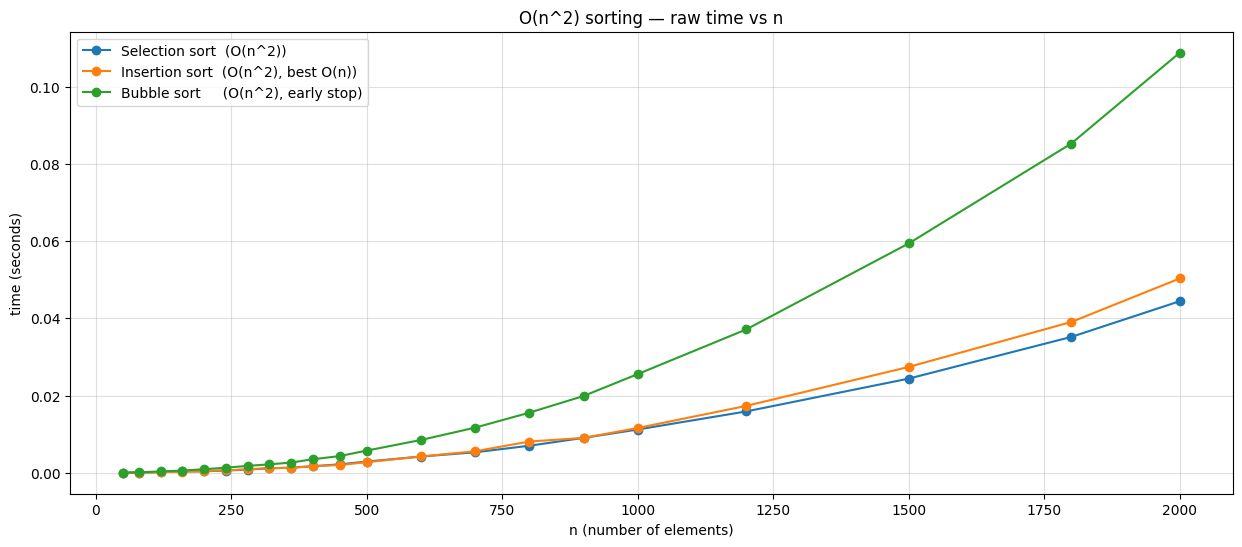

In [4]:
# ---------------------------------------------------------
# Plot 1: raw time vs n
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))
for name in results:
    plt.plot(ns, results[name], marker="o", label=name)

plt.title("O(n^2) sorting — raw time vs n")
plt.xlabel("n (number of elements)"); plt.ylabel("time (seconds)")
plt.legend(); plt.grid(True, alpha=0.4); plt.show()


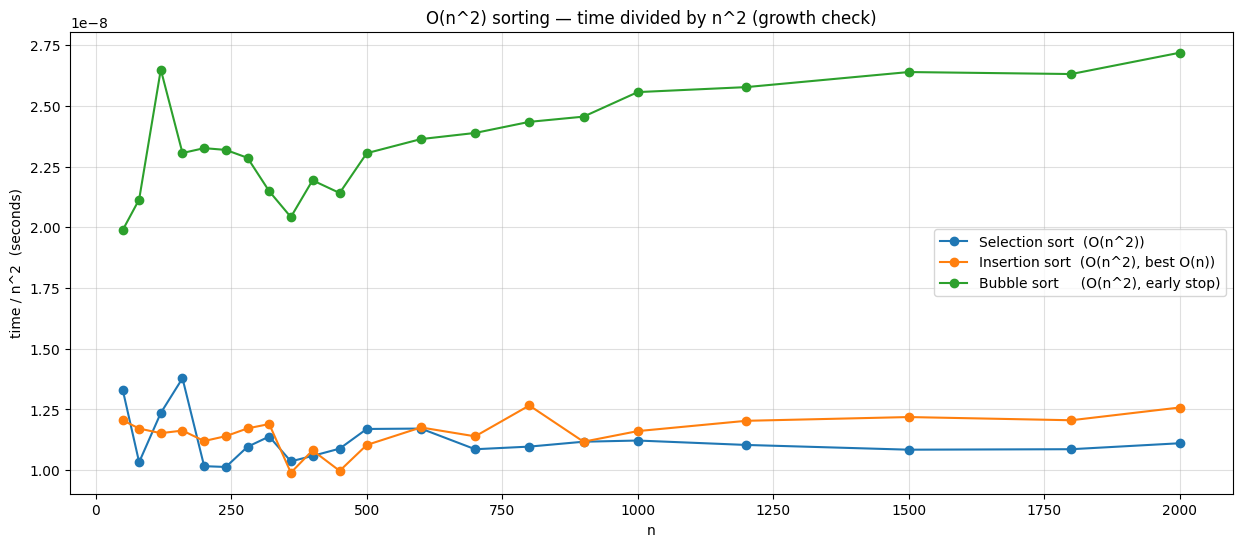


Didactic takeaway:
• Raw time increases fast as n grows.
• If an algorithm is truly ~O(n^2), then time / n^2 should look roughly constant.
• Insertion sort may look better on nearly-sorted data (best case O(n)).


In [5]:
# -----------------------------------------------------------------------
# Plot 2: normalized by n^2  (should be ~flat for true quadratic growth)
# -----------------------------------------------------------------------

plt.figure(figsize=(15, 6))
for name in results:
    normalized = [t / (n * n) for t, n in zip(results[name], ns)]
    plt.plot(ns, normalized, marker="o", label=name)

plt.title("O(n^2) sorting — time divided by n^2 (growth check)")
plt.xlabel("n"); plt.ylabel("time / n^2  (seconds)")
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

print("\nDidactic takeaway:")
print("• Raw time increases fast as n grows.")
print("• If an algorithm is truly ~O(n^2), then time / n^2 should look roughly constant.")
print("• Insertion sort may look better on nearly-sorted data (best case O(n)).")


### `Python sort() (TimSort): show O(n log n)`

In [7]:
import time
import math
import random
import matplotlib.pyplot as plt
from typing import Callable, Dict, List



def time_call(fn: Callable[[], None], *, repeats: int) -> float:
    times: List[float] = []
    for _ in range(repeats):
        t0: float = time.perf_counter()
        fn()
        t1: float = time.perf_counter()
        times.append(t1 - t0)
    times.sort()
    return times[len(times) // 2]



In [ ]:

random.seed(7)

# Larger N is okay because Python sort is fast
ns: List[int] = [1_000, 2_000, 4_000, 8_000, 16_000, 32_000, 64_000]
datasets: Dict[int, List[int]] = {n: [random.randint(0, 10_000_000) for _ in range(n)] for n in ns}

times_sort: List[float] = []

print("-" * 70)
print(f"{'Benchmark: Python sort() (TimSort) — expected ~ O(n log n)':^70}")
print("-" * 70)

for n in ns:
    arr = datasets[n]

    def run_sort(*, arr: List[int]) -> None:
        b = arr.copy()
        b.sort()

    elapsed = time_call(fn=lambda arr=arr: run_sort(arr=arr), repeats=7)
    times_sort.append(elapsed)
    print(f"n={n:<7}  sort()  {elapsed:.6f} s")


In [9]:
ns

[1000, 2000, 4000, 8000, 16000, 32000, 64000]

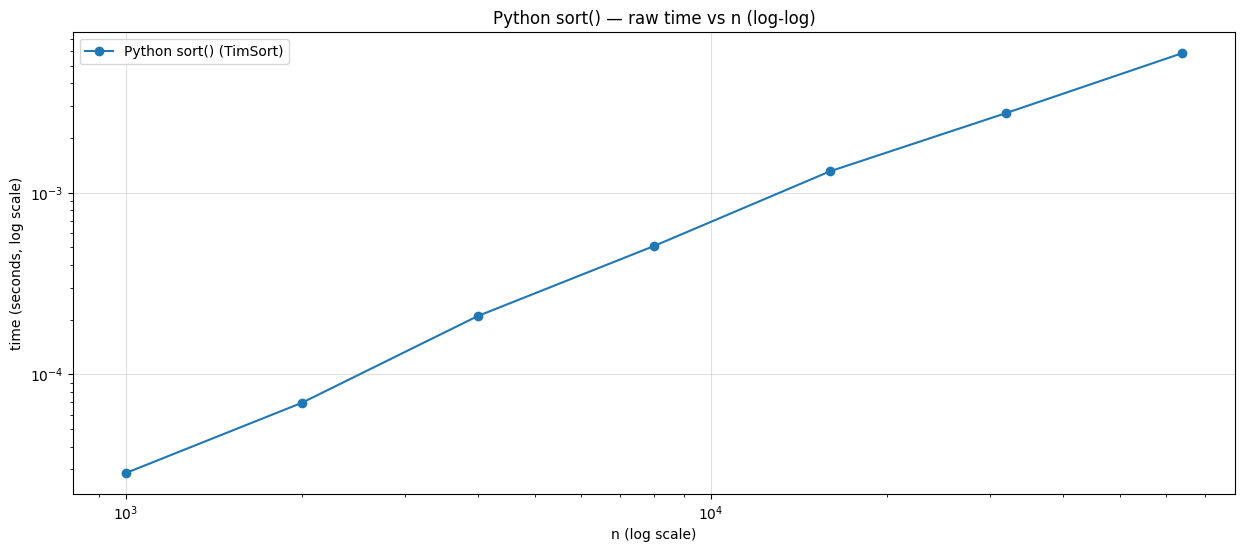

In [11]:

# ---------------------------------------------------------
# Plot 1: raw time vs n (log-log makes growth clearer)
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))
plt.plot(ns, times_sort, marker="o", label="Python sort() (TimSort)")
plt.xscale("log"); plt.yscale("log")
plt.title("Python sort() — raw time vs n (log-log)")
plt.xlabel("n (log scale)"); plt.ylabel("time (seconds, log scale)")
plt.legend(), plt.grid(True, alpha=0.4); plt.show()



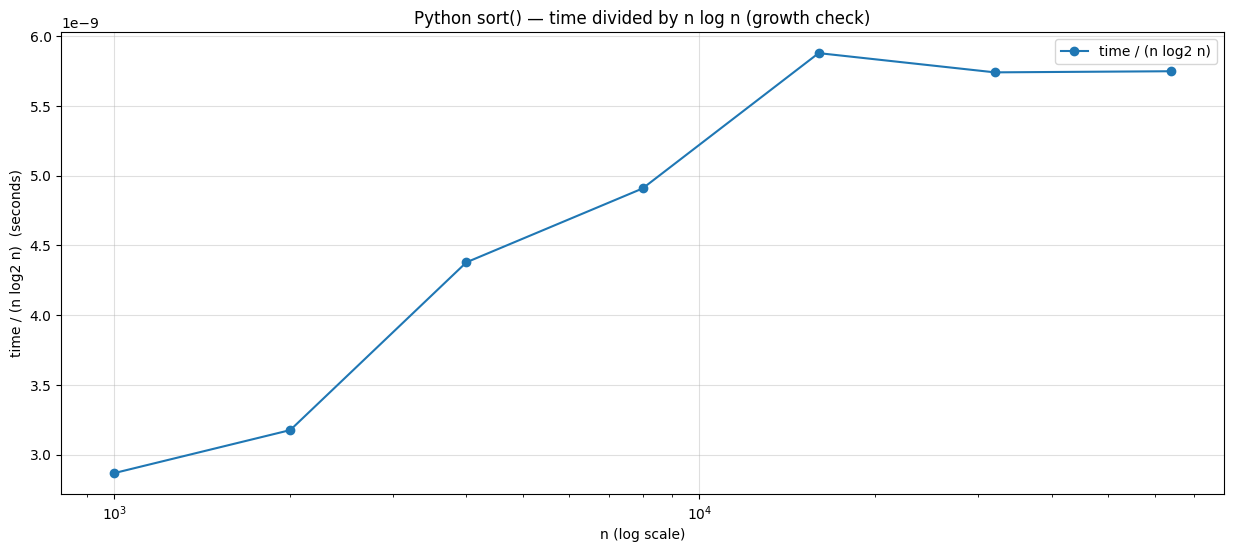


Didactic takeaway:
• Comparison sorting has a lower bound Ω(n log n).
• Python’s sort() is highly optimized; it typically behaves ~O(n log n) on random data.
• If time / (n log n) is roughly flat, that supports the n log n growth model.


In [14]:
# ---------------------------------------------------------
# Plot 2: normalize by n log2(n) (should be ~flat for n log n)
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))
norm: List[float] = []
for t, n in zip(times_sort, ns):
    denom = n * math.log2(n)
    norm.append(t / denom)

plt.plot(ns, norm, marker="o", label="time / (n log2 n)")
plt.xscale("log")
plt.title("Python sort() — time divided by n log n (growth check)")
plt.xlabel("n (log scale)"); plt.ylabel("time / (n log2 n)  (seconds)")
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

print("\nDidactic takeaway:")
print("• Comparison sorting has a lower bound Ω(n log n).")
print("• Python’s sort() is highly optimized; it typically behaves ~O(n log n) on random data.")
print("• If time / (n log n) is roughly flat, that supports the n log n growth model.")

### `Counting sort (small range M): show O(n + M) ~ linear when M is small`

In [16]:
import time
import random
import matplotlib.pyplot as plt
from typing import Callable, Dict, List


def counting_sort_small_range(a: List[int], *, m: int) -> List[int]:
    """
    Counting sort for values in [0, m).
    Complexity: O(n + m)
    """
    cnt: List[int] = [0] * m
    for v in a:
        cnt[v] += 1

    res: List[int] = []
    # Rebuild result
    for value, c in enumerate(cnt):
        if c > 0:
            # Fast-ish in Python for repeating values
            res.extend([value] * c)
    return res


def time_call(fn: Callable[[], None], *, repeats: int) -> float:
    times: List[float] = []
    for _ in range(repeats):
        t0: float = time.perf_counter()
        fn()
        t1: float = time.perf_counter()
        times.append(t1 - t0)
    times.sort()
    return times[len(times) // 2]


In [17]:
random.seed(7)

# We keep M small to demonstrate the "linear when range is small" point
M: int = 100

ns: List[int] = [1_000, 2_000, 5_000, 10_000, 20_000, 40_000, 80_000, 160_000]
datasets: Dict[int, List[int]] = {n: [random.randrange(0, M) for _ in range(n)] for n in ns}

times_counting: List[float] = []
times_timsort: List[float] = []

print("-" * 70)
print(f"{'Benchmark: Counting sort (M small) vs Python sort()':^70}")
print("-" * 70)
print(f"M (value range size) = {M}")

for n in ns:
    arr = datasets[n]

    # counting sort
    elapsed_count = time_call(
        fn=lambda arr=arr: counting_sort_small_range(arr, m=M),
        repeats=5,
    )

    # python sort
    elapsed_sort = time_call(
        fn=lambda arr=arr: sorted(arr),
        repeats=7,
    )

    times_counting.append(elapsed_count)
    times_timsort.append(elapsed_sort)

    print(f"n={n:<7}  counting_sort={elapsed_count:.6f}s   sort()={elapsed_sort:.6f}s")



----------------------------------------------------------------------
         Benchmark: Counting sort (M small) vs Python sort()          
----------------------------------------------------------------------
M (value range size) = 100
n=1000     counting_sort=0.000041s   sort()=0.000029s
n=2000     counting_sort=0.000071s   sort()=0.000067s
n=5000     counting_sort=0.000134s   sort()=0.000215s
n=10000    counting_sort=0.000252s   sort()=0.000430s
n=20000    counting_sort=0.000494s   sort()=0.001044s
n=40000    counting_sort=0.001084s   sort()=0.002239s
n=80000    counting_sort=0.002353s   sort()=0.004609s
n=160000   counting_sort=0.004908s   sort()=0.009277s


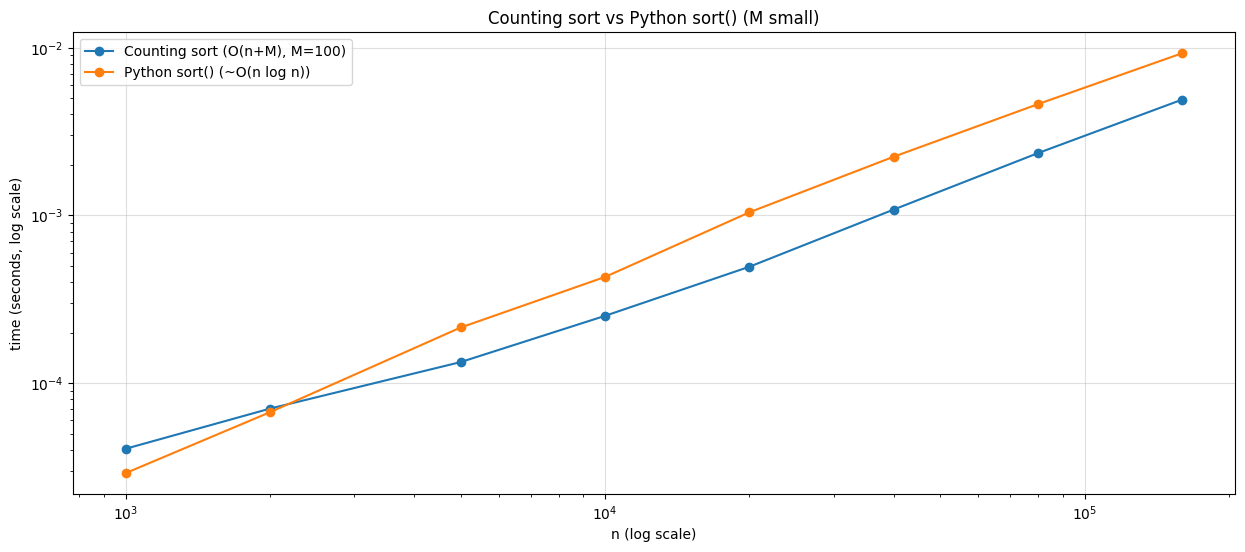

In [20]:
# ---------------------------------------------------------
# Plot 1: raw time
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))
plt.plot(ns, times_counting, marker="o", label=f"Counting sort (O(n+M), M={M})")
plt.plot(ns, times_timsort, marker="o", label="Python sort() (~O(n log n))")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("time (seconds, log scale)")
plt.title("Counting sort vs Python sort() (M small)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()



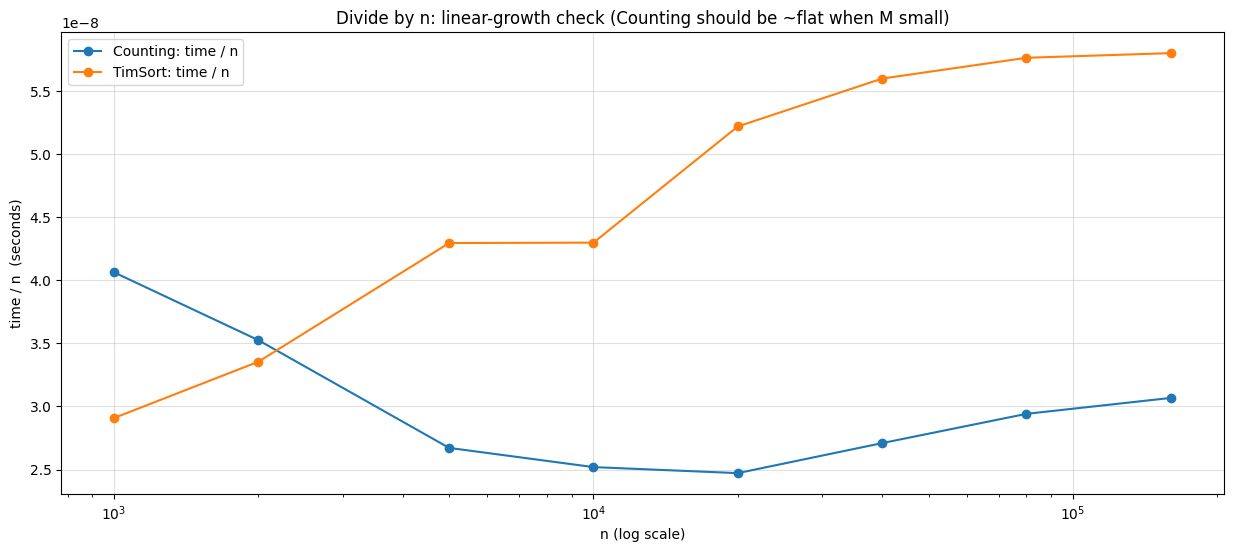


Didactic takeaway:
• Counting sort can beat n log n because it is NOT comparison-only; it uses the value range.
• With M small and fixed, counting sort behaves ~O(n).
• If time / n is roughly flat for counting sort, that supports linear growth.


In [21]:
# ---------------------------------------------------------
# Plot 2: normalize by n (linear check)
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))
plt.plot(ns, [t / n for t, n in zip(times_counting, ns)], marker="o", label="Counting: time / n")
plt.plot(ns, [t / n for t, n in zip(times_timsort, ns)], marker="o", label="TimSort: time / n")
plt.xscale("log")
plt.xlabel("n (log scale)")
plt.ylabel("time / n  (seconds)")
plt.title("Divide by n: linear-growth check (Counting should be ~flat when M small)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print("\nDidactic takeaway:")
print("• Counting sort can beat n log n because it is NOT comparison-only; it uses the value range.")
print("• With M small and fixed, counting sort behaves ~O(n).")
print("• If time / n is roughly flat for counting sort, that supports linear growth.")